## The preprocessing journey starts here 🌠

### First things first, the imports, the part where we try to gather the tools that we would need to get this task done 🔨

In [116]:
import cv2 as cv                            # OpenCV: industry standard for image processing
import numpy as np                          # NumPy: math and array operations
import matplotlib.pyplot as plt             # Matplotlib: display images
import os                                   # os: file and folder operations
import shutil                               # shutil: copy/move files
from sklearn.model_selection import train_test_split  # scikit-learn: split data

### After that, its time to define the preprocessing functions that we would need to make the data ready for our models to learn from 😎

Our first function would be for validating that all images are grayscale.

In [117]:
# First step is that to ensure the image we are working with is grayscale, as the color doesn't add a lot of info that we need in our applications
# which is concerned with expressions recognition.
def validate_grayscale(image):
    """"Ensure the image is 2D (grayscale). If RGB, convert to grayscale"""
    
    if len(image.shape) == 3:                               # If image has 3 dimensions (height, width, color_channels)
        return cv.cvtColor(image, cv.COLOR_BGR2GRAY)      # Convert to grayscale (2D: height, width only)
    
    else:
        return image                                        # Otherwise, it's already grayscale 

Why grayscale for facial expression?

- Facial expressions (happy, sad, angry) are about shape and texture, not color.
- Emotion is in the eyes, mouth, and eyebrows—all visible in grayscale.
- Grayscale uses less memory and is faster to process.
- FER2013 dataset is already grayscale (48×48 pixels), so you'll rarely need conversion, but it's a safety check.

The second function would be for smoothing the images to remove the noise.

In [118]:
def apply_gaussian_blur(image, kernal_size = (3, 3)): # remember to search for what this sigma actually do, how it makes things differ
    """Apply Gaussian Blur to remove high-frequency noise. """
    return cv.GaussianBlur(image, kernal_size, 0)

    #  image          → input grayscale image
    #  kernel_size    → (3, 3) = 3x3 neighborhood
    #  0              → sigma (standard deviation) = auto-compute from kernel size

Why blur for facial expression?

- Real-world images are noisy (camera sensor noise, compression artifacts).
- Noise can fool classifiers later (the model thinks random speckles are part of the expression).
- Blur removes this noise without losing facial structure.

What is kernel_size?

- The kernel is a small square neighborhood that moves over the image.
- kernel_size=(3, 3) means look at a 3×3 square (the center pixel and its 8 neighbors).
- For each 3×3 square, compute the weighted average (Gaussian weight means center pixels matter more than edge pixels).

Visual analogy:<br>
Imagine a 3×3 grid of pixels:
```
100   150   120
140   200    80
110   160   130
```  

Gaussian blur computes a weighted average (center weight=4, edge weights=1, corner weights=0.5):

result ≈ (200×4 <br>+ 100×2  <br>+ 150×2 <br>+ 120×1 <br>+ 140×2 <br>+ 80×1 <br>+ 110×1 <br>+ 160×2 <br>+ 130×1) / sum_of_weights <br> <br>
result ≈ 135

Now the time has come for the big boys, the contrast boosting (but with a small catch) 😉

In [119]:
def apply_clahe_opencv(image, clip_limit = 1.0, tile_grid_size = (8, 8)):
    """Apply CLAHE(Contrast Limited Adaptive Histogram Equalization) using openCV."""
    clahe = cv.createCLAHE(clipLimit = clip_limit, tileGridSize = tile_grid_size) # Returns an object of the class CLAHE with the specific attributes that we've inputed.
    return clahe.apply(image) # Applies CLAHE on the desired image.

Why CLAHE for facial expression?

- Facial expressions live in details: eyebrow curves, mouth shape, eye wideness.
- These details are often subtle in raw images (eyes are very dark, cheeks are very bright).
- CLAHE makes these subtle details pop without over-amplifying noise.

Understanding the parameters:
<br>
<br>clip_limit=2.0: How much to boost contrast before "clipping" extreme values.
<br>
<br>Low value (≈1): little contrast boost, safer
<br>High value (≈4): aggressive boost, can amplify noise
<br>2.0 is a balanced choice
<br>tile_grid_size=(8, 8): Divide the image into 8×8 = 64 small tiles.
<br>
<br>Each tile gets its own contrast boost.
<br>Why? Because the shadow on the left side of a face is different from the shadow on the right.
<br>If we boosted globally, we'd over-boost one side.
***

Intuition:
<br>Think of a face photo taken in poor lighting:

<br>Eyes are black (values ≈ 10–50)
<br>Forehead is grayish (values ≈ 150–200)
<br>Cheeks are in between
<br>CLAHE says: "In the eye region, stretch 10–50 to use the full 0–255 range. In the forehead region, stretch 150–200 to use more range." This reveals expression details.

***
Finally, we'll wrap our helping functions for preprocessing with the bilateral filtering.

In [120]:
def apply_bilateral_filter(image, d = 9, sigma_color = 75, sigma_space = 75): # search more for sigma space and sigma color
    """Apply Bilateral Filtering to denoise while preserving edges."""
    return cv.bilateralFilter(image, d, sigma_color, sigma_space)

# Understanding the parameters:

# d = 9: Diameter of the pixel neighborhood (9 pixels wide).
# 
# Larger d → more smoothing but slower
# 9 is typical for faces
# sigma_color = 75: How different two pixels can be and still be blurred together.
# 
# Values 0–255 (pixel brightness range)
# 75 ≈ moderate threshold (pixels within 75 brightness units get blurred together)
# Higher value → blurs across more edges (less detail preservation)
# Lower value → keeps more edges (more detail)
# sigma_space = 75: Spatial (distance-based) weight.
# 
# Controls how much distance matters when deciding which pixels to average.
# 75 means pixels up to ~75 pixels away can influence each other
# Larger = more smoothing

The problem with regular blur and thus why bilateral filtering:

- Gaussian blur averages ALL nearby pixels equally.
- This blurs edges too, making fine facial lines fuzzy.
- You lose eyebrow shape, mouth curves, eye boundaries.

What is Bilateral Filtering?

- It's a smart blur that says: "Average nearby pixels, BUT only if they have similar brightness."
- This preserves edges (where brightness suddenly changes) while smoothing flat areas.

***
Now let's put it all together in one main function.

In [121]:
def apply_sharpening_filter(image):
    """Sharpen edges using a simple convolution kernel."""
    kernel = np.array([
        [0, -1, 0],
        [-1, 5, -1],
        [0, -1, 0]
    ])
    return cv.filter2D(image, -1, kernel)

In [122]:
def preprocess_image(image_path):
    """Full pipeline for preprocessing a single image."""

    img = cv.imread(image_path, cv. IMREAD_GRAYSCALE)
    
    if img is None:
        return None
    
    
    img = validate_grayscale(img)
    # img = apply_gaussian_blur(img)
    img = apply_sharpening_filter(img)
    # img = apply_clahe_opencv(img)
    # img = apply_bilateral_filter(img)

    return img

In [123]:
def sharpen_with_detected_edges(image):
    image = preprocess_image(image)
    # Detect edges
    edges = cv.Canny(image, 50, 150)

    # Connect broken edges
    kernel = np.ones((3, 3), np.uint8)
    edges = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel)

    # Make edge map stronger
    edges = cv.dilate(edges, kernel, iterations=1)

    # Combine edges with original image
    sharpened = cv.addWeighted(image, 1.0, edges, 0.5, 0)

    return sharpened

Why this order matters:

1. Load → Get the raw image
2. Validate grayscale → Ensure we're working with 2D data
3. Gaussian blur → Remove high-frequency noise first (easiest stage)
4. CLAHE → Boost contrast while details are cleaner
5. Bilateral filter → Final gentle smooth that preserves edges and expression details

Why NOT a different order?

- If you did bilateral first, you'd smooth noise + expression details together.
- If you did CLAHE first, you'd amplify noise before removing it.
- This order is science-backed for facial image preprocessing.

Full workflow visualization:

```Original noisy face
         ↓
     [Blur] → removes sensor/compression noise
         ↓
    [CLAHE] → reveals hidden expression details (eyes, mouth contrast)
         ↓
[Bilateral] → final smooth while keeping expression edges sharp
         ↓
   Clean face ready for feature extraction
   ```

In [124]:
def apply_unsharp_masking(image, kernel_size=(5, 5), k=1.0):
    """
    Apply Unsharp Masking based on the formula:
    
    g_mask(x,y) = f(x,y) - f̄(x,y)   where f̄ is the blurred image
    g(x,y) = f(x,y) + k * g_mask(x,y)
    
    Parameters:
    - image: input grayscale image
    - kernel_size: size of Gaussian blur kernel (must be odd)
    - k: sharpening strength
        k=1.0   → standard unsharp masking
        k>1.0   → highboost filtering (very sharp)
        k<1.0   → less sharpening
        k=0.0   → no sharpening (just the original)
    """
    # Step 1: Create blurred version
    blurred = cv.GaussianBlur(image, kernel_size, 0)
    
    # Step 2: Create mask (detail layer) = original - blurred
    # We subtract to extract the high-frequency details
    mask = image.astype(np.float32) - blurred.astype(np.float32)
    
    # Step 3: Apply the sharpening formula
    # g(x,y) = f(x,y) + k * mask
    sharpened = image.astype(np.float32) + k * mask
    
    # Step 4: Clip values to valid range [0, 255]
    sharpened = np.clip(sharpened, 0, 255).astype(np.uint8)
    
    return sharpened


def apply_unsharp_masking_with_comparison(image, kernel_size=(5, 5)):
    """
    Apply unsharp masking with THREE different k values for comparison.
    Returns original, k=0.5 (mild), k=1.0 (standard), k=1.5 (strong)
    """
    unsharp_mild = apply_unsharp_masking(image, kernel_size, k=0.5)
    unsharp_standard = apply_unsharp_masking(image, kernel_size, k=0.4)
    unsharp_strong = apply_unsharp_masking(image, kernel_size, k=0.3)
    
    return unsharp_mild, unsharp_standard, unsharp_strong

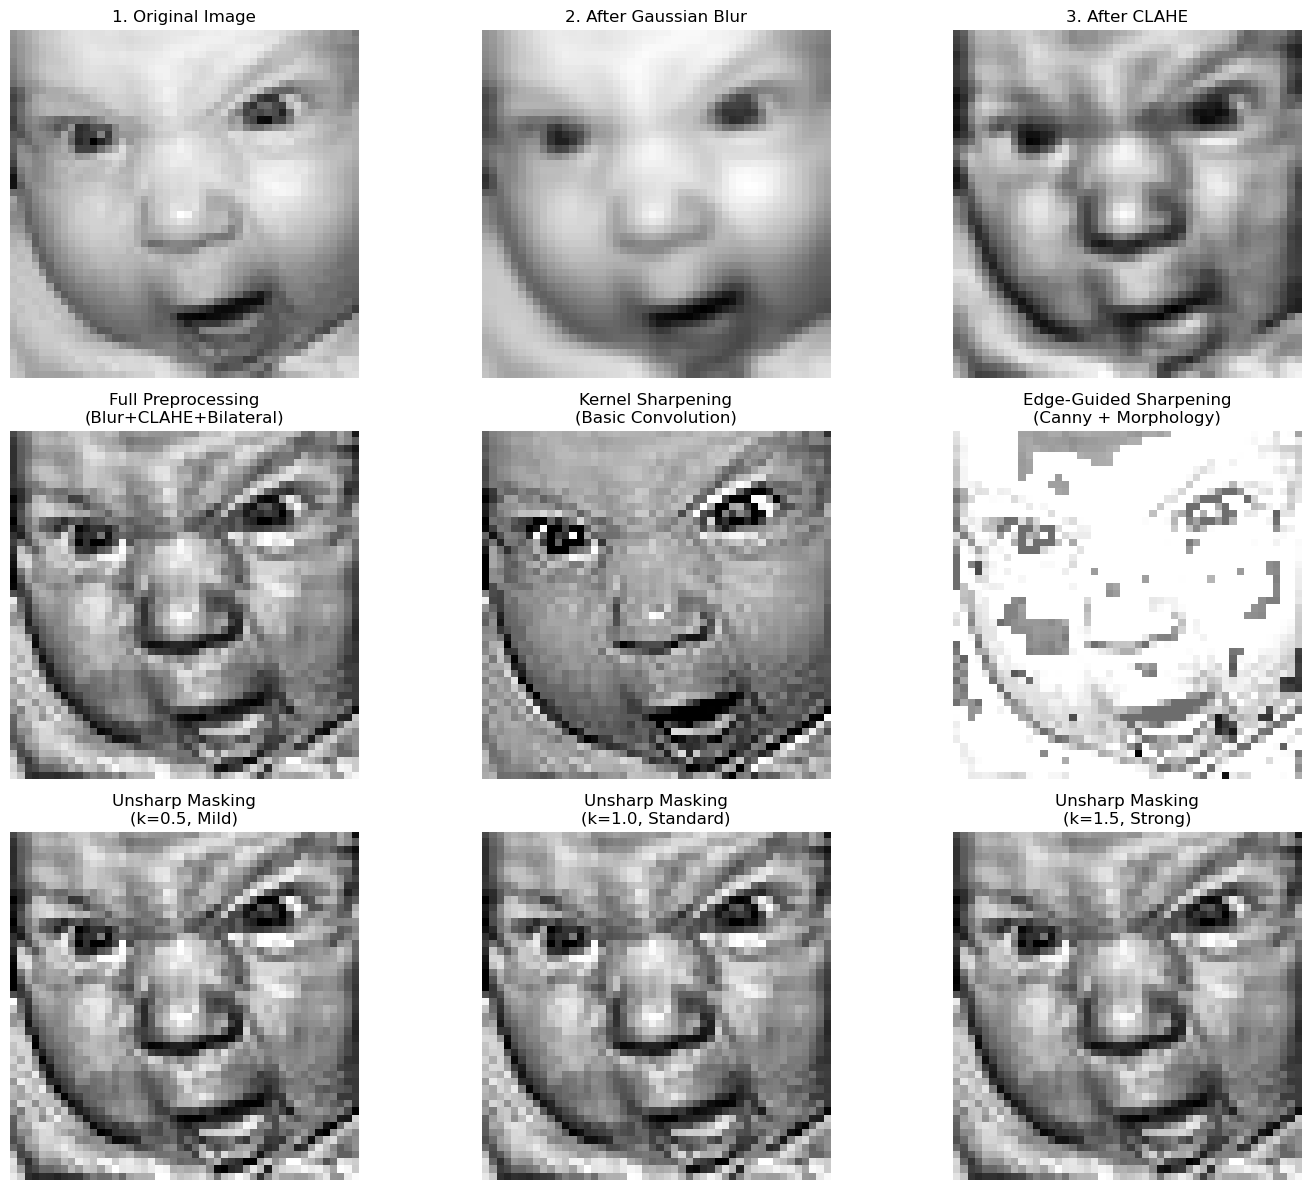


PIXEL VALUE STATISTICS
Original          - Min:   9, Max: 196, Mean:  133.5, Std:   35.0
Preprocessed      - Min:   0, Max: 255, Mean:  139.6, Std:   54.3
Kernel Sharpened  - Min:   0, Max: 255, Mean:  134.6, Std:   49.8
Edges Sharpened   - Min:  33, Max: 255, Mean:  229.4, Std:   41.1
Unsharp k=0.5     - Min:   0, Max: 255, Mean:  139.8, Std:   57.3
Unsharp k=1.0     - Min:   0, Max: 255, Mean:  139.6, Std:   55.8
Unsharp k=1.5     - Min:   0, Max: 255, Mean:  139.6, Std:   54.3

INTERPRETATION:
- Higher Mean: brighter overall (may indicate over-sharpening)
- Higher Std: more variation (can mean more detail or more noise)
- Min=0, Max=255 range: full dynamic range utilization


In [ ]:
# ============================================================================
# COMPREHENSIVE SHARPENING COMPARISON TEST
# ============================================================================

image_path = "../fer2013/versions/1/test/fear/PrivateTest_22817278.jpg"

# Load original
original = cv.imread(image_path, cv.IMREAD_GRAYSCALE)

# Build the preprocessing pipeline
img_preprocessed = original.copy()
img_preprocessed = validate_grayscale(img_preprocessed)
# img_preprocessed = apply_bilateral_filter(img_preprocessed)
# img_preprocessed = apply_sharpening_filter(img_preprocessed)
img_preprocessed = apply_clahe_opencv(img_preprocessed)
img_preprocessed = apply_unsharp_masking(img_preprocessed, kernel_size=(5, 5), k = 0.3)

# img_preprocessed = apply_gaussian_blur(img_preprocessed)

# Test different sharpening methods
clahe_img = apply_clahe_opencv(original)
img_kernel_sharpened = apply_sharpening_filter(original)

img_edges_sharpened = sharpen_with_detected_edges(image_path)

# Unsharp masking variants
img_unsharp_mild, img_unsharp_standard, img_unsharp_strong = \
    apply_unsharp_masking_with_comparison(clahe_img, kernel_size=(5, 5))

# Create 3-row display showing progression
fig, axes = plt.subplots(3, 3, figsize=(15, 12))

# Row 1: Original and basic preprocessing stages
axes[0, 0].imshow(original, cmap="gray")
axes[0, 0].set_title("1. Original Image")
axes[0, 0].axis("off")

axes[0, 1].imshow(apply_gaussian_blur(original), cmap="gray")
axes[0, 1].set_title("2. After Gaussian Blur")
axes[0, 1].axis("off")

axes[0, 2].imshow(apply_clahe_opencv(apply_gaussian_blur(original)), cmap="gray")
axes[0, 2].set_title("3. After CLAHE")
axes[0, 2].axis("off")

# Row 2: Full preprocessing vs simple sharpening
axes[1, 0].imshow(img_preprocessed, cmap="gray")
axes[1, 0].set_title("Full Preprocessing\n(Blur+CLAHE+Bilateral)")
axes[1, 0].axis("off")

axes[1, 1].imshow(img_kernel_sharpened, cmap="gray")
axes[1, 1].set_title("Kernel Sharpening\n(Basic Convolution)")
axes[1, 1].axis("off")

axes[1, 2].imshow(img_edges_sharpened, cmap="gray")
axes[1, 2].set_title("Edge-Guided Sharpening\n(Canny + Morphology)")
axes[1, 2].axis("off")

# Row 3: Unsharp masking variants
axes[2, 0].imshow(img_unsharp_mild, cmap="gray")
axes[2, 0].set_title("Unsharp Masking\n(k=0.5, Mild)")
axes[2, 0].axis("off")

axes[2, 1].imshow(img_unsharp_standard, cmap="gray")
axes[2, 1].set_title("Unsharp Masking\n(k=1.0, Standard)")
axes[2, 1].axis("off")

axes[2, 2].imshow(img_unsharp_strong, cmap="gray")
axes[2, 2].set_title("Unsharp Masking\n(k=1.5, Strong)")
axes[2, 2].axis("off")

plt.tight_layout()
plt.show()

# Print pixel statistics to compare intensity distributions
print("\n" + "="*70)
print("PIXEL VALUE STATISTICS")
print("="*70)
print(f"Original          - Min: {original.min():3d}, Max: {original.max():3d}, Mean: {original.mean():6.1f}, Std: {original.std():6.1f}")
print(f"Preprocessed      - Min: {img_preprocessed.min():3d}, Max: {img_preprocessed.max():3d}, Mean: {img_preprocessed.mean():6.1f}, Std: {img_preprocessed.std():6.1f}")
print(f"Kernel Sharpened  - Min: {img_kernel_sharpened.min():3d}, Max: {img_kernel_sharpened.max():3d}, Mean: {img_kernel_sharpened.mean():6.1f}, Std: {img_kernel_sharpened.std():6.1f}")
print(f"Edges Sharpened   - Min: {img_edges_sharpened.min():3d}, Max: {img_edges_sharpened.max():3d}, Mean: {img_edges_sharpened.mean():6.1f}, Std: {img_edges_sharpened.std():6.1f}")
print(f"Unsharp k=0.5     - Min: {img_unsharp_mild.min():3d}, Max: {img_unsharp_mild.max():3d}, Mean: {img_unsharp_mild.mean():6.1f}, Std: {img_unsharp_mild.std():6.1f}")
print(f"Unsharp k=1.0     - Min: {img_unsharp_standard.min():3d}, Max: {img_unsharp_standard.max():3d}, Mean: {img_unsharp_standard.mean():6.1f}, Std: {img_unsharp_standard.std():6.1f}")
print(f"Unsharp k=1.5     - Min: {img_unsharp_strong.min():3d}, Max: {img_unsharp_strong.max():3d}, Mean: {img_unsharp_strong.mean():6.1f}, Std: {img_unsharp_strong.std():6.1f}")
print("="*70)
print("\nINTERPRETATION:")
print("- Higher Mean: brighter overall (may indicate over-sharpening)")
print("- Higher Std: more variation (can mean more detail or more noise)")
print("- Min=0, Max=255 range: full dynamic range utilization")

In [126]:
def apply_unsharp_then_edges(image, k=0.5, canny_low=30, canny_high=100):
    """
    Advanced pipeline: Apply unsharp masking then edge detection.
    
    This combines enhancement with segmentation:
    1. Apply unsharp masking to enhance boundaries (k=0.5 is mild)
    2. Apply Canny edge detection on the enhanced image
    3. Result: a map showing facial region boundaries
    
    Parameters:
    - image: input grayscale image
    - k: unsharp masking strength (0.5 = mild enhancement)
    - canny_low, canny_high: edge detection thresholds
    """
    
    # Step 1: Apply unsharp masking to enhance boundaries
    unsharpened = apply_unsharp_masking(image, kernel_size=(5, 5), k=k)
    
    # Step 2: Apply Canny edge detection on the enhanced image
    edges = cv.Canny(unsharpened, canny_low, canny_high)
    
    # Step 3: Clean up the edge map with morphology
    kernel = np.ones((2, 2), np.uint8)
    edges_cleaned = cv.morphologyEx(edges, cv.MORPH_CLOSE, kernel, iterations=1)
    
    # Step 4: Dilate slightly to make edges visible
    edges_cleaned = cv.dilate(edges_cleaned, kernel, iterations=1)
    
    return unsharpened, edges, edges_cleaned


def visualize_edge_detection_pipeline(image_path, k=0.5):
    """
    Full visualization of: Original → CLAHE → Unsharp → Edges → Cleaned Edges
    """
    original = cv.imread(image_path, cv.IMREAD_GRAYSCALE)
    
    if original is None:
        print(f"Error: Could not load image from {image_path}")
        return
    
    # Apply CLAHE first (as in your pipeline)
    clahe_img = apply_clahe_opencv(original)
    
    # Apply unsharp + edges
    unsharp_img, edges_raw, edges_cleaned = apply_unsharp_then_edges(clahe_img, k=k)
    
    # Create 2x2 comparison grid
    fig, axes = plt.subplots(2, 2, figsize=(12, 12))
    
    # Top-left: Original with CLAHE
    axes[0, 0].imshow(clahe_img, cmap="gray")
    axes[0, 0].set_title("Step 1: CLAHE Enhanced Image\n(baseline for edge detection)")
    axes[0, 0].axis("off")
    
    # Top-right: After unsharp masking
    axes[0, 1].imshow(unsharp_img, cmap="gray")
    axes[0, 1].set_title(f"Step 2: Unsharp Masking (k={k})\n(boundaries enhanced)")
    axes[0, 1].axis("off")
    
    # Bottom-left: Raw edges
    axes[1, 0].imshow(edges_raw, cmap="gray")
    axes[1, 0].set_title("Step 3: Canny Edge Detection\n(raw edges from enhanced image)")
    axes[1, 0].axis("off")
    
    # Bottom-right: Cleaned edges
    axes[1, 1].imshow(edges_cleaned, cmap="gray")
    axes[1, 1].set_title("Step 4: Morphologically Cleaned Edges\n(facial region boundaries)")
    axes[1, 1].axis("off")
    
    plt.tight_layout()
    plt.show()
    
    # Print analysis
    print("\n" + "="*70)
    print("EDGE DETECTION ANALYSIS")
    print("="*70)
    print(f"Original image shape: {original.shape}")
    print(f"Edge pixels (raw):    {np.sum(edges_raw > 0):6d} / {original.size:6d} ({100*np.sum(edges_raw > 0)/original.size:.2f}%)")
    print(f"Edge pixels (cleaned):{np.sum(edges_cleaned > 0):6d} / {original.size:6d} ({100*np.sum(edges_cleaned > 0)/original.size:.2f}%)")
    print("\nINTERPRETATION:")
    print("- Higher edge percentage: more boundaries detected")
    print("- Cleaned edges should form coherent facial region boundaries")
    print("- Look for: eyes, mouth, eyebrows, face outline")
    print("="*70)
    
    return clahe_img, unsharp_img, edges_raw, edges_cleaned

Testing edge detection after unsharp masking (k=0.5)...


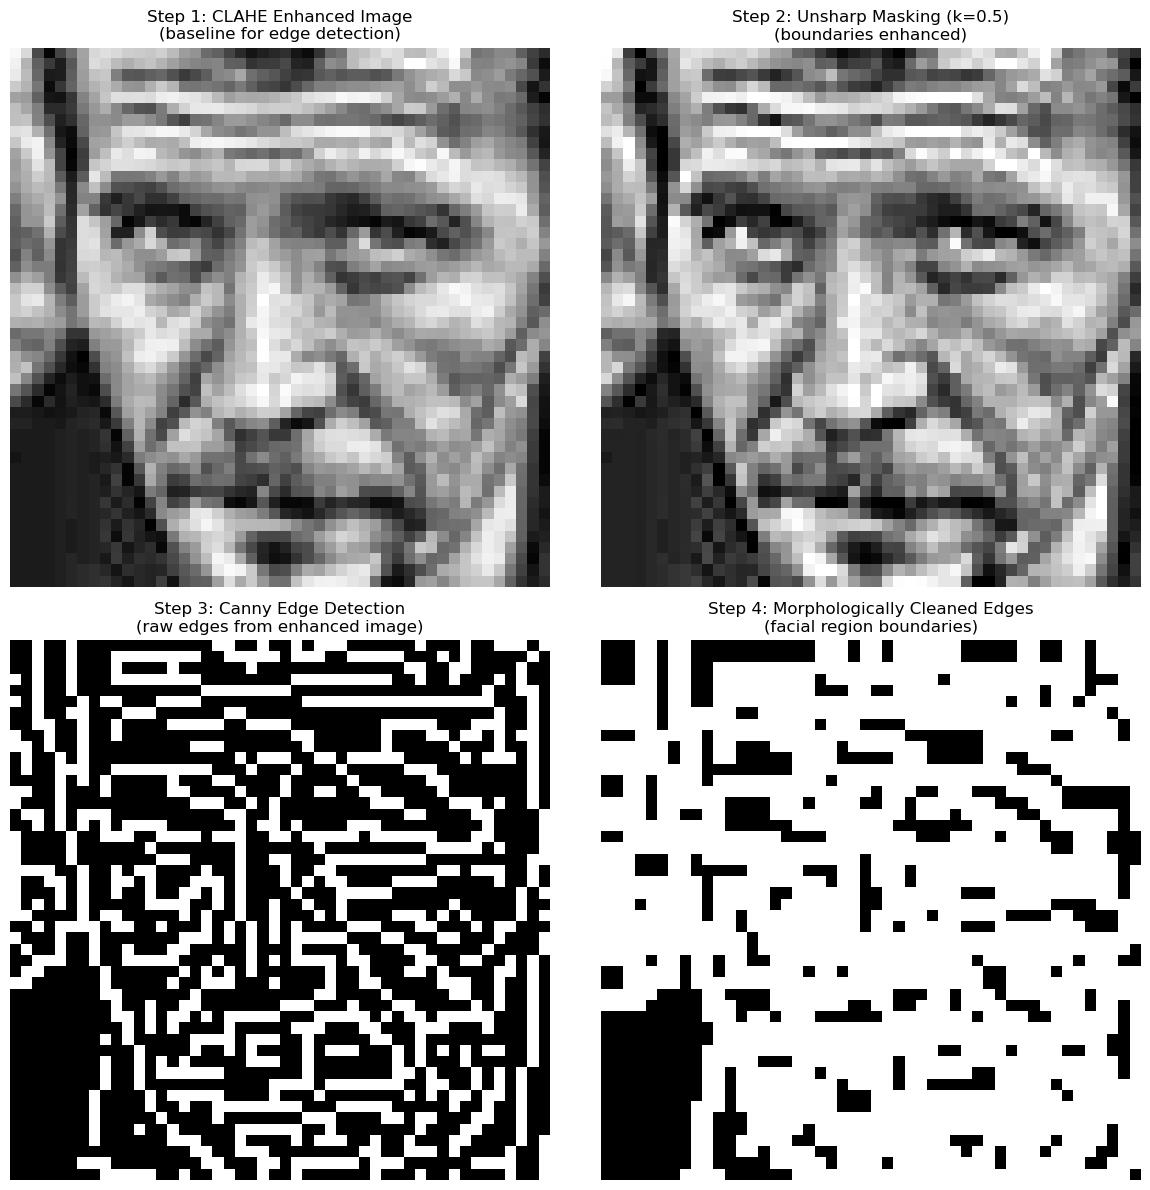


EDGE DETECTION ANALYSIS
Original image shape: (48, 48)
Edge pixels (raw):       803 /   2304 (34.85%)
Edge pixels (cleaned):  1719 /   2304 (74.61%)

INTERPRETATION:
- Higher edge percentage: more boundaries detected
- Cleaned edges should form coherent facial region boundaries
- Look for: eyes, mouth, eyebrows, face outline


Comparing different k values for unsharp masking...
k=0.3: 74.13% edge pixels detected
k=0.5: 74.61% edge pixels detected
k=0.7: 75.22% edge pixels detected


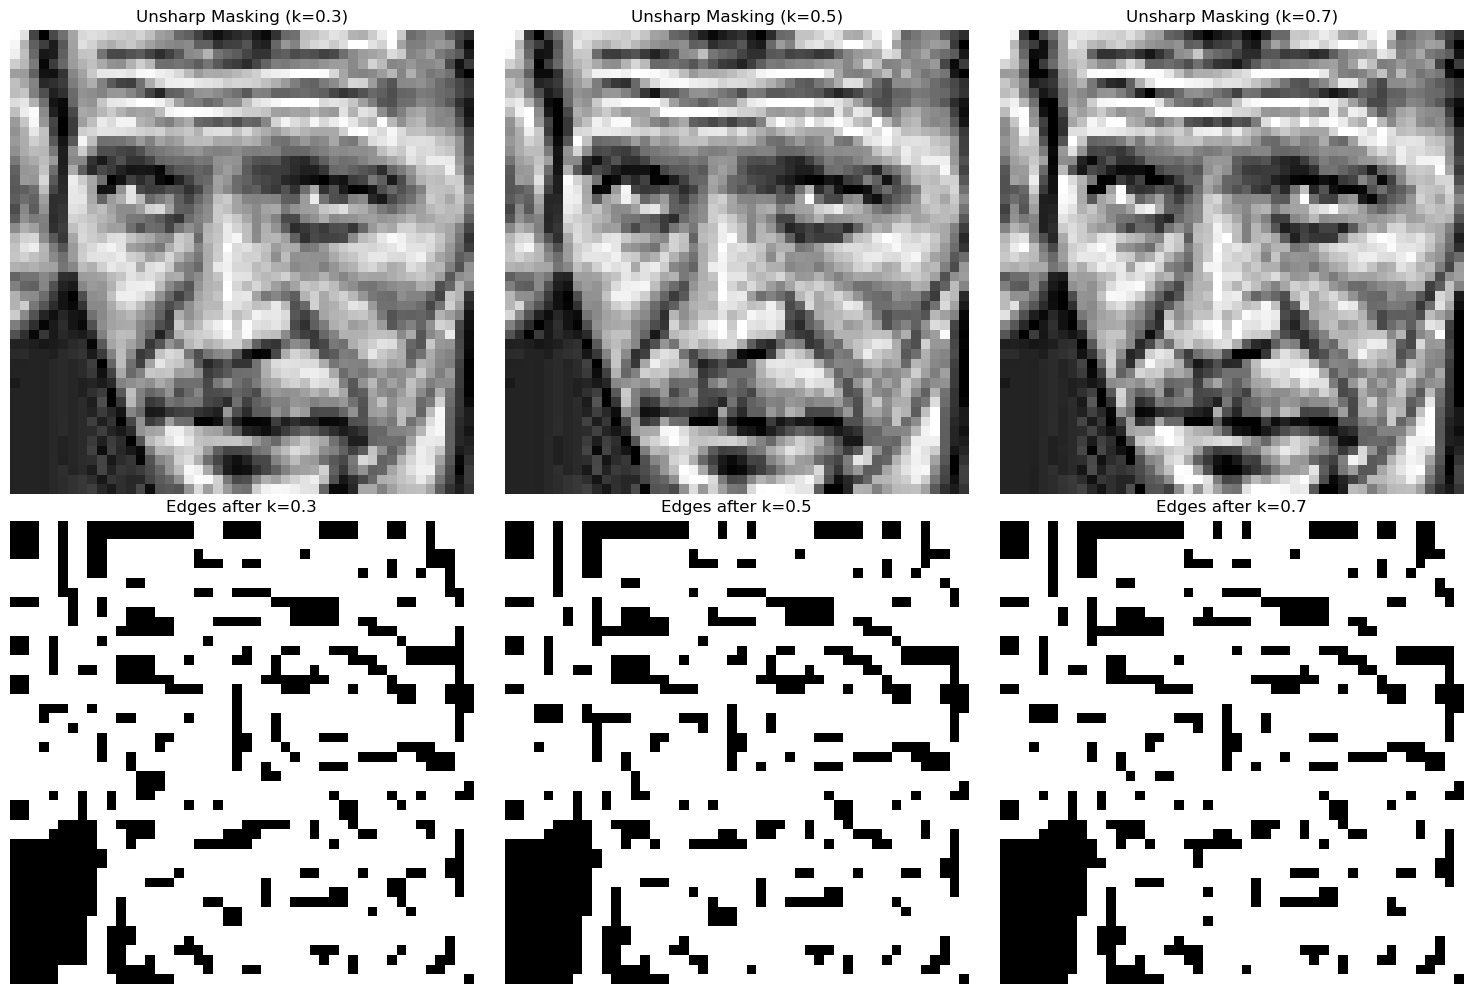


OBSERVATION QUESTIONS:
1. Which k value (0.3, 0.5, 0.7) gives the clearest facial boundaries?
2. Can you see eyes, mouth, eyebrows, and face outline in the edges?
3. Is there excessive noise in any of the edge maps?
4. Which method (k=0.5 or others) best separates facial regions?


In [ ]:
# ============================================================================
# EDGE DETECTION AFTER UNSHARP MASKING - FACIAL REGION SEGMENTATION
# ============================================================================

image_path = "../fer2013/versions/1/test/neutral/PrivateTest_2117908.jpg"

# Test with k=0.5 (mild unsharp)
print("Testing edge detection after unsharp masking (k=0.5)...")
clahe_img, unsharp_img, edges_raw, edges_cleaned = visualize_edge_detection_pipeline(
    image_path, 
    k=0.5
)

# Optional: Try with different k values to compare
print("\n\nComparing different k values for unsharp masking...")

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

k_values = [0.3, 0.5, 0.7]

for idx, k in enumerate(k_values):
    unsharp, edges_raw, edges_cleaned = apply_unsharp_then_edges(
        clahe_img, 
        k=k
    )
    
    # Top row: Unsharp masked images
    axes[0, idx].imshow(unsharp, cmap="gray")
    axes[0, idx].set_title(f"Unsharp Masking (k={k})")
    axes[0, idx].axis("off")
    
    # Bottom row: Corresponding edge maps
    axes[1, idx].imshow(edges_cleaned, cmap="gray")
    axes[1, idx].set_title(f"Edges after k={k}")
    axes[1, idx].axis("off")
    
    # Print stats
    edge_percentage = 100 * np.sum(edges_cleaned > 0) / edges_cleaned.size
    print(f"k={k}: {edge_percentage:.2f}% edge pixels detected")

plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("OBSERVATION QUESTIONS:")
print("="*70)
print("1. Which k value (0.3, 0.5, 0.7) gives the clearest facial boundaries?")
print("2. Can you see eyes, mouth, eyebrows, and face outline in the edges?")
print("3. Is there excessive noise in any of the edge maps?")
print("4. Which method (k=0.5 or others) best separates facial regions?")
print("="*70)